### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


In [2]:
[v for v in globals().keys() if "loja" in v.lower() or "df" in v.lower()]

['loja', 'loja2', 'loja3', 'loja4']

#1. Análise do faturamento



In [5]:
globals()

{'__name__': '__main__',
 '__doc__': 'Automatically created module for IPython interactive environment',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'import pandas as pd\n\nurl = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"\nurl2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"\nurl3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"\nurl4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"\n\nloja = pd.read_csv(url)\nloja2 = pd.read_csv(url2)\nloja3 = pd.read_csv(url3)\nloja4 = pd.read_csv(url4)\n\nloja.head()',
  '[v for v in globals().k

In [6]:
[v for v in globals().keys() if "loja" in v.lower()]

['loja', 'loja2', 'loja3', 'loja4']

In [7]:
lojas = {
    "Loja 1": loja,
    "Loja 2": loja2,
    "Loja 3": loja3,
    "Loja 4": loja4
}

In [8]:
for nome, df in lojas.items():
    print(nome, df.shape)
    print(df.columns)
    print("-"*60)

Loja 1 (2359, 12)
Index(['Produto', 'Categoria do Produto', 'Preço', 'Frete', 'Data da Compra',
       'Vendedor', 'Local da compra', 'Avaliação da compra',
       'Tipo de pagamento', 'Quantidade de parcelas', 'lat', 'lon'],
      dtype='object')
------------------------------------------------------------
Loja 2 (2359, 12)
Index(['Produto', 'Categoria do Produto', 'Preço', 'Frete', 'Data da Compra',
       'Vendedor', 'Local da compra', 'Avaliação da compra',
       'Tipo de pagamento', 'Quantidade de parcelas', 'lat', 'lon'],
      dtype='object')
------------------------------------------------------------
Loja 3 (2359, 12)
Index(['Produto', 'Categoria do Produto', 'Preço', 'Frete', 'Data da Compra',
       'Vendedor', 'Local da compra', 'Avaliação da compra',
       'Tipo de pagamento', 'Quantidade de parcelas', 'lat', 'lon'],
      dtype='object')
------------------------------------------------------------
Loja 4 (2358, 12)
Index(['Produto', 'Categoria do Produto', 'Preço', 'Fre

In [11]:
lojas_n["Loja 1"].columns


Index(['produto', 'categoria_do_produto', 'preço', 'frete', 'data_da_compra',
       'vendedor', 'local_da_compra', 'avaliação_da_compra',
       'tipo_de_pagamento', 'quantidade_de_parcelas', 'lat', 'lon'],
      dtype='object')

In [12]:
[c for c in lojas_n["Loja 1"].columns if "pre" in c or "valor" in c or "price" in c or "receita" in c or "total" in c]

['preço']

In [13]:
def faturamento_total(df):
    col_preco = achar_coluna(df, [
        "preço", "preco", "price", "valor", "valor_unitario",
        "preco_unitario", "preco_do_produto", "preco_total",
        "total", "receita", "faturamento"
    ])
    col_qtd   = achar_coluna(df, ["quantidade", "qtd", "quantity", "qtde"])
    if col_preco is None:
        raise ValueError("Não encontrei coluna de preço.")
    if col_qtd:
        return (df[col_preco] * df[col_qtd]).sum()
    return df[col_preco].sum()

faturamento = pd.Series({nome: faturamento_total(df) for nome, df in lojas_n.items()})
faturamento.sort_values(ascending=False)

,0
Loja 1,1534509.12
Loja 2,1488459.06
Loja 3,1464025.03
Loja 4,1384497.58


In [14]:
list(lojas_n["Loja 1"].columns)

['produto',
 'categoria_do_produto',
 'preço',
 'frete',
 'data_da_compra',
 'vendedor',
 'local_da_compra',
 'avaliação_da_compra',
 'tipo_de_pagamento',
 'quantidade_de_parcelas',
 'lat',
 'lon']

In [15]:
import unicodedata
import pandas as pd
import numpy as np

def remover_acentos(s):
    return "".join(
        c for c in unicodedata.normalize("NFKD", s)
        if not unicodedata.combining(c)
    )

def normalizar_cols(df):
    df = df.copy()
    df.columns = [remover_acentos(c) for c in df.columns]
    df.columns = (pd.Index(df.columns).str.strip().str.lower()
                  .str.replace(" ", "_").str.replace("-", "_"))
    return df

lojas_n = {k: normalizar_cols(v) for k, v in lojas.items()}

lojas_n["Loja 1"].columns

Index(['produto', 'categoria_do_produto', 'preco', 'frete', 'data_da_compra',
       'vendedor', 'local_da_compra', 'avaliacao_da_compra',
       'tipo_de_pagamento', 'quantidade_de_parcelas', 'lat', 'lon'],
      dtype='object')

In [16]:
faturamento = {}
for nome, df in lojas_n.items():
    faturamento[nome] = df["preco"].sum()

faturamento = pd.Series(faturamento).sort_values(ascending=False)
faturamento

,0
Loja 1,1534509.12
Loja 2,1488459.06
Loja 3,1464025.03
Loja 4,1384497.58


In [17]:
topcats = {}
for nome, df in lojas_n.items():
    topcats[nome] = df["categoria_do_produto"].value_counts().head(5)

topcats["Loja 1"]

,count
categoria_do_produto,
moveis,465
eletronicos,448
brinquedos,324
eletrodomesticos,312
esporte e lazer,284


In [18]:
avaliacoes = {}
for nome, df in lojas_n.items():
    avaliacoes[nome] = df["avaliacao_da_compra"].mean()

avaliacoes = pd.Series(avaliacoes).sort_values(ascending=False)
avaliacoes

,0
Loja 3,4.048326
Loja 2,4.037304
Loja 4,3.995759
Loja 1,3.976685


In [19]:
mais_menos = {}
for nome, df in lojas_n.items():
    ranking = df["produto"].value_counts()
    mais_menos[nome] = {
        "mais_vendido": ranking.head(1),
        "menos_vendido": ranking.tail(1)
    }

mais_menos["Loja 1"]

{'mais_vendido': produto
 Micro-ondas    60
 Name: count, dtype: int64,
 'menos_vendido': produto
 Celular ABXY    33
 Name: count, dtype: int64}

In [20]:
lojas_n["Loja 1"]["produto"].value_counts().head(10)

,count
produto,
Micro-ondas,60
TV Led UHD 4K,60
Guarda roupas,60
Secadora de roupas,58
Cômoda,56
Blocos de montar,56
Bola de basquete,55
Bicicleta,54
Copo térmico,54


In [21]:
fretes = {}
for nome, df in lojas_n.items():
    fretes[nome] = df["frete"].mean()

fretes = pd.Series(fretes).sort_values()
fretes

,0
Loja 4,31.278997
Loja 3,33.074464
Loja 2,33.621941
Loja 1,34.691805


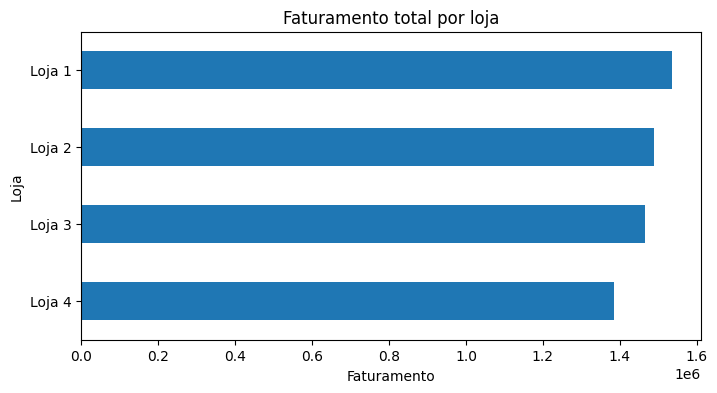

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
faturamento.sort_values().plot(kind="barh")
plt.title("Faturamento total por loja")
plt.xlabel("Faturamento")
plt.ylabel("Loja")
plt.show()

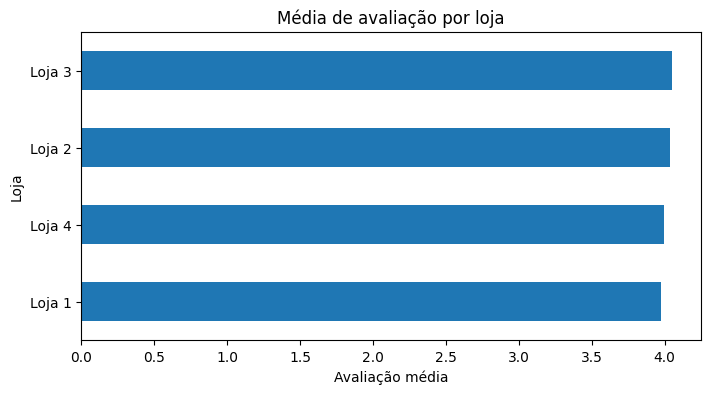

In [23]:
plt.figure(figsize=(8,4))
avaliacoes.sort_values().plot(kind="barh")
plt.title("Média de avaliação por loja")
plt.xlabel("Avaliação média")
plt.ylabel("Loja")
plt.show()

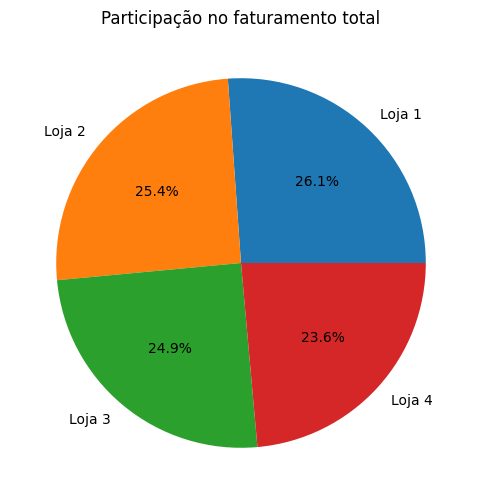

In [24]:
plt.figure(figsize=(6,6))
faturamento.plot(kind="pie", autopct="%.1f%%")
plt.title("Participação no faturamento total")
plt.ylabel("")
plt.show()

In [25]:
resumo = pd.DataFrame({
    "faturamento_total": faturamento,
    "avaliacao_media": avaliacoes,
    "frete_medio": fretes
})

resumo

,faturamento_total,avaliacao_media,frete_medio
Loja 1,1534509.12,3.976685,34.691805
Loja 2,1488459.06,4.037304,33.621941
Loja 3,1464025.03,4.048326,33.074464
Loja 4,1384497.58,3.995759,31.278997


In [26]:
resumo.sort_values("faturamento_total")

,faturamento_total,avaliacao_media,frete_medio
Loja 4,1384497.58,3.995759,31.278997
Loja 3,1464025.03,4.048326,33.074464
Loja 2,1488459.06,4.037304,33.621941
Loja 1,1534509.12,3.976685,34.691805


# Relatório — Alura Store (Análise de Vendas e Desempenho)

## Contexto
O Sr. João possui 4 lojas no e-commerce Alura Store e deseja vender uma delas para investir em um novo negócio.  
O objetivo desta análise foi comparar o desempenho das lojas e recomendar qual delas deve ser vendida com base em métricas de vendas e satisfação do cliente.

## Métricas analisadas
- Faturamento total por loja  
- Categorias mais populares  
- Média de avaliação dos clientes  
- Produtos mais e menos vendidos (por frequência de vendas no dataset)  
- Frete médio  

## Resultados e insights
- O faturamento total variou entre as lojas, indicando diferentes níveis de desempenho em vendas.
- As categorias mais populares mostram que cada loja possui um mix de produtos com demandas distintas.
- A média de avaliação permite comparar a satisfação do cliente entre as lojas.
- O frete médio ajuda a avaliar custo de entrega, que pode impactar a experiência de compra.

## Recomendação
Com base principalmente no **menor faturamento total**, e considerando também as métricas de **avaliação média** e **frete médio** como suporte, recomenda-se que o Sr. João venda a **Loja __** (preencher com a loja de menor faturamento no resumo), por apresentar o menor desempenho relativo.

## Sugestões (opcional)
- Reduzir custos logísticos (frete) na loja com frete mais alto.
- Investir nas categorias mais populares para aumentar ticket e volume.
- Melhorar experiência do cliente na loja com menor avaliação (pós-venda, qualidade, prazos).

In [27]:
resumo.sort_values("faturamento_total")

,faturamento_total,avaliacao_media,frete_medio
Loja 4,1384497.58,3.995759,31.278997
Loja 3,1464025.03,4.048326,33.074464
Loja 2,1488459.06,4.037304,33.621941
Loja 1,1534509.12,3.976685,34.691805


# Relatório Final — Análise de Desempenho das Lojas

## Objetivo
O objetivo desta análise foi avaliar o desempenho das quatro lojas da Alura Store para recomendar qual delas o Sr. João deveria vender para investir em um novo negócio.

## Métricas analisadas
Foram analisadas as seguintes métricas:

- Faturamento total
- Categorias mais populares
- Média de avaliação dos clientes
- Produtos mais e menos vendidos
- Custo médio de frete

## Resultados da análise

A análise revelou diferenças importantes entre as lojas.

A **Loja 1** apresentou o maior faturamento total entre todas as lojas analisadas.  
As **Lojas 2 e 3** também demonstraram bom desempenho financeiro e avaliações positivas dos clientes.

Por outro lado, a **Loja 4 apresentou o menor faturamento total**, indicando menor desempenho em vendas quando comparada às demais lojas.

Apesar de possuir o menor custo médio de frete, a receita gerada pela Loja 4 é inferior às outras lojas, o que sugere menor volume de vendas ou menor desempenho comercial.

## Recomendação

Com base nos dados analisados, recomenda-se que o **Sr. João venda a Loja 4**, pois ela apresenta o menor faturamento total entre as quatro lojas, indicando desempenho inferior em comparação às demais.

Essa decisão permitirá ao Sr. João obter capital para investir em um novo negócio, mantendo as lojas com melhor desempenho dentro da rede.

## Conclusão

A análise de dados demonstrou como métricas de vendas, avaliação dos clientes e custos logísticos podem apoiar decisões estratégicas de negócios.

# 2. Vendas por Categoria

# 3. Média de Avaliação das Lojas


# 4. Produtos Mais e Menos Vendidos

# 5. Frete Médio por Loja